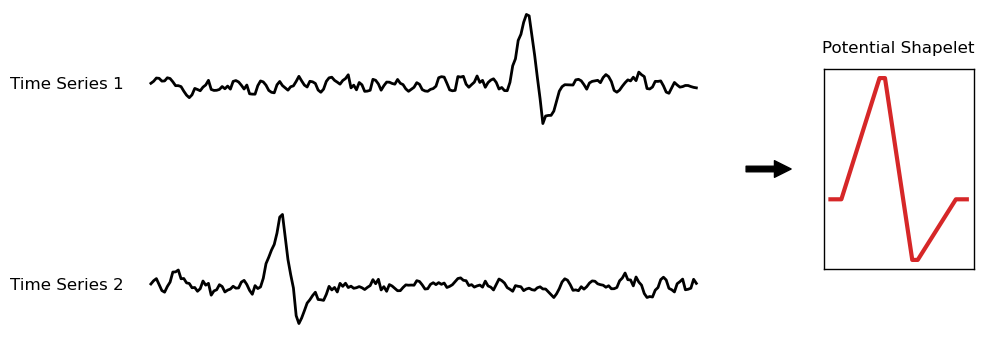

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducible background noise
np.random.seed(42)

# Create the x-axis arrays
t1 = np.linspace(0, 10, 200)
t2 = np.linspace(0, 10, 200)

# Create baseline noisy signals
noise1 = np.random.normal(0, 0.4, 200)
noise2 = np.random.normal(0, 0.4, 200)

# Smooth the noise slightly to match the drawing style
noise1 = np.convolve(noise1, np.ones(3)/3, mode='same')
noise2 = np.convolve(noise2, np.ones(3)/3, mode='same')

# Create the NEW shapelet: A sharp, asymmetrical spike
shapelet_len = 40
new_shapelet = np.zeros(shapelet_len)
new_shapelet[10:18] = np.linspace(0, 3, 8)    # Sharp rise
new_shapelet[18:24] = np.linspace(3, -1.5, 6) # Sharp drop below baseline
new_shapelet[24:32] = np.linspace(-1.5, 0, 8) # Return to baseline

# Initialize time series with the smoothed noise
ts1 = noise1.copy()
ts2 = noise2.copy()

# Inject the new shapelet into different locations in both time series
# Time Series 1: Spike towards the right
ts1[120:160] += new_shapelet
# Time Series 2: Spike towards the left
ts2[30:70] += new_shapelet

# Set up the figure layout
fig = plt.figure(figsize=(10, 4))
fig.patch.set_facecolor('white')

# Plot Time Series 1
ax1 = plt.axes([0.1, 0.6, 0.6, 0.3])
ax1.plot(t1, ts1, color='black', linewidth=2)
ax1.axis('off')
ax1.text(-0.5, np.mean(ts1), 'Time Series 1', va='center', ha='right', fontsize=12)

# Plot Time Series 2
ax2 = plt.axes([0.1, 0.1, 0.6, 0.3])
ax2.plot(t2, ts2, color='black', linewidth=2)
ax2.axis('off')
ax2.text(-0.5, np.mean(ts2), 'Time Series 2', va='center', ha='right', fontsize=12)

# Add the directional arrow
ax_arrow = plt.axes([0.72, 0.45, 0.05, 0.1])
ax_arrow.axis('off')
ax_arrow.annotate('', xy=(1, 0.5), xytext=(0, 0.5), 
                  arrowprops=dict(facecolor='black', shrink=0.05, width=4, headwidth=12))

# Plot the isolated Potential Shapelet Box
shapelet_t = np.linspace(0, 1, shapelet_len)
ax3 = plt.axes([0.8, 0.25, 0.15, 0.5])
# Trim the flat edges slightly for the display box to focus on the shape
ax3.plot(shapelet_t[8:34], new_shapelet[8:34], color='#d62728', linewidth=3)
ax3.set_xticks([])
ax3.set_yticks([])
ax3.set_title('Potential Shapelet', pad=12, fontsize=12)

# Add a black border around the shapelet box
for spine in ax3.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1)

plt.show()